In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('bmh')
plt.rcParams['axes.facecolor'] = 'white'

In [2]:
df_anom = pd.read_csv(
    '../data/anomaly_meteo-2.csv', 
    index_col=['Unnamed: 0'],
    parse_dates=['position_timestamp']
)
df_anom.info()

<class 'pandas.DataFrame'>
RangeIndex: 5750 entries, 0 to 5749
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype              
---  ------              --------------  -----              
 0   position_timestamp  5750 non-null   datetime64[us, UTC]
 1   latitude            5750 non-null   float64            
 2   longitude           5750 non-null   float64            
 3   speed               5750 non-null   float64            
 4   course              5750 non-null   float64            
 5   heading             5750 non-null   float64            
 6   currentDirection    5750 non-null   float64            
 7   currentSpeed        5750 non-null   float64            
 8   gust                5750 non-null   float64            
 9   swellDirection      5394 non-null   float64            
 10  swellHeight         5394 non-null   float64            
 11  time                5750 non-null   str                
 12  waveDirection       5750 non-null   float64  

In [3]:
df_anom = df_anom.rename(columns={
    'course': 'COG',
    'heading': 'Heading',
    'position_timestamp': '# Timestamp',
    'latitude': 'Latitude',
    'longitude': 'Longitude',
    'speed': 'SOG'
})
df_anom['MMSI'] = 414270000

In [4]:
from datetime import timedelta

import sys
sys.path.append('..')

from sklearn.preprocessing import MinMaxScaler
from src.data_preparation import feature_engineering, prepare_time_series

Smoothing: False


### The following has been taken from src/data_prep/data_preparation.py

In [5]:
dfs = []
above_interpolation_limit = 0

df_anom['Heading'] = np.clip( df_anom['Heading'], 0, 360 )
df_anom['COG'] = np.clip( df_anom['COG'], 0, 360 )

df_anom['hour'] = df_anom['# Timestamp'].dt.round('h')
df_anom = df_anom.drop(columns=['hour'])

df_anom, timestamps = feature_engineering(df_anom, return_timestamps=True)

In [6]:
df_anom['swellDirection_vec_x'] = df_anom['swellDirection_vec_x'].bfill()
df_anom['swellHeight'] = df_anom['swellHeight'].interpolate('pchip')

#### MinMaxScaler has to be reused from training, validation and test set preparation

In [7]:
import pickle

In [8]:
min_max_scale_cols = [
    'SOG',
    'currentSpeed',
    'gust',
    'swellHeight',
    'waveHeight',
    'windSpeed'
]

with open('../output/min-max-scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

df_anom[min_max_scale_cols] = scaler.fit_transform(
    df_anom[min_max_scale_cols].values
)

# Prepare time series and concatenate
# initialize arrays as null
X_train, y_train, X_val, y_val, X_test, y_test = [None] * 6

In [10]:
df_anom.dropna(inplace=True)
df_anom.drop(columns=['time'], inplace=True)

df_anom_smooth = df_anom.copy(deep=True)
df_anom_smooth = df_anom_smooth\
    .rolling(25)\
    .mean()

df_anom_smooth.dropna(inplace=True)

In [11]:
df_anom_smooth['swellDirection_vec_x'].isnull()

25      False
26      False
27      False
28      False
29      False
        ...  
5745    False
5746    False
5747    False
5748    False
5749    False
Name: swellDirection_vec_x, Length: 5369, dtype: bool

In [12]:
X_arr_smooth, y_arr_smooth = prepare_time_series(df_anom_smooth)

In [13]:
np.save( '../anom-x.npy', X_arr_smooth )
np.save( '../anom-y.npy', y_arr_smooth )

In [14]:
X_arr_reverse = X_arr_smooth[::-1, ::-1, :]
y_arr_reverse = y_arr_smooth[::-1, ::-1, :]

np.save( '../anom-x-reverse.npy', X_arr_smooth )
np.save( '../anom-y-reverse.npy', y_arr_smooth )

In [11]:
import tensorflow as tf
from src.experiments.functions import quantile_loss, BATCH_SIZE

2026-03-18 16:00:30.996331: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-18 16:00:31.130725: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773842431.180800   14102 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773842431.195318   14102 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773842431.302304   14102 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [21]:
model_high_smooth = tf.keras.models.load_model(
    '../output/model-0.025-COGoutput.keras',
    custom_objects={
        'Custom>quantile_loss_function': quantile_loss(0.025)
    }
)
model_low_smooth = tf.keras.models.load_model(
    '../output/model-0.975-COGoutput.keras',
    custom_objects={
        'Custom>quantile_loss_function': quantile_loss(0.975)
    }
)

In [22]:
y_high_smooth = model_high_smooth.predict(X_arr_smooth)
y_low_smooth = model_low_smooth.predict(X_arr_smooth)

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


In [23]:
y_arr_smooth

array([[[-0.15972404],
        [-0.15944566],
        [-0.1593099 ],
        ...,
        [-0.16855968],
        [-0.16904856],
        [-0.16949168]],

       [[-0.16015746],
        [-0.15972404],
        [-0.15944566],
        ...,
        [-0.16811012],
        [-0.16855968],
        [-0.16904856]],

       [[-0.16075101],
        [-0.16015746],
        [-0.15972404],
        ...,
        [-0.16781098],
        [-0.16811012],
        [-0.16855968]],

       ...,

       [[-0.37839238],
        [-0.37859516],
        [-0.37896211],
        ...,
        [-0.36380116],
        [-0.36197894],
        [-0.36006232]],

       [[-0.37771089],
        [-0.37839238],
        [-0.37859516],
        ...,
        [-0.36550245],
        [-0.36380116],
        [-0.36197894]],

       [[-0.37541152],
        [-0.37771089],
        [-0.37839238],
        ...,
        [-0.36710245],
        [-0.36550245],
        [-0.36380116]]])

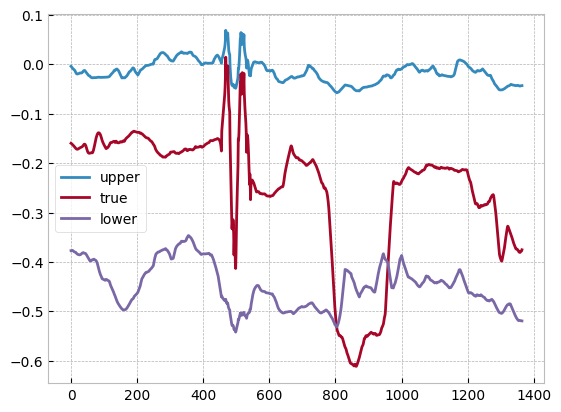

In [25]:
plt.plot( y_low_smooth[:, 0].ravel(), label='upper')
plt.plot( y_arr_smooth[:, 0].ravel(), label='true')
plt.plot( y_high_smooth[:, 0].ravel(), label='lower')
plt.legend()

In [16]:
timestamps_not_smooth = timestamps[26:-25]
timestamps_smooth = timestamps[50:-25]

In [17]:
from datetime import datetime

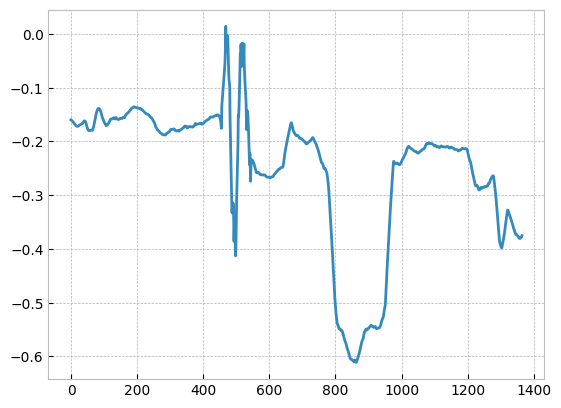

In [24]:
plt.plot(y_arr_smooth[:, 0])

NameError: name 'y_true' is not defined

In [18]:
def plot_pi(y_true, y_low, y_high, variable_name: str, timestamps: pd.Series):

    anomalies_x = []
    anomalies_y = []
    for i in range(y_true.shape[0]):

        if y_true[i] < y_low[i]:
            anomalies_x.append( timestamps[i] )
            anomalies_y.append( y_true[i] )

        elif y_true[i] > y_high[i]:
            anomalies_x.append( timestamps[i] )
            anomalies_y.append( y_true[i] )

    plt.plot(timestamps, y_low, label='Prognozės\nintervalas', lw=1, linestyle='--', color='#0D77A7')
    plt.plot(timestamps, y_high, lw=1, linestyle='--', color='#0D77A7')
    plt.fill_between(x=timestamps, y1=y_low, y2=y_high, alpha=0.2)
    plt.plot(timestamps, y_true, label='Tikroji\nreikšmė', lw=1.5, color='black')

    plt.scatter(anomalies_x, anomalies_y, color='red', label='Anomalijos')

    plt.ylabel(variable_name, size=20)
    plt.title(f'Laivo Yi-Peng 3\n{variable_name} incidento metu', size=22)

    plt.tick_params(axis='both', labelsize=18)
    plt.xticks(
        ticks=[datetime(2024, 11, 18, 0, 0), datetime(2024, 11, 18, 12, 0), datetime(2024, 11, 19, 0, 0)],
        labels=['2024-11-18\n00:00 UTC', '2024-11-18\n12:00 UTC', '2024-11-19\n00:00 UTC']
    )

    plt.legend()
    plt.tight_layout()
    plt.savefig('delta_dif_old.png', dpi=750)

    plt.show()

plot_pi(
    y_arr_smooth[:, 0, 0],
    y_low_smooth[:, 0, 0],
    y_high_smooth[:, 0, 0],
    r'$\Delta dif^*$',
    timestamps_smooth
)

IndexError: index 1364 is out of bounds for axis 0 with size 1364

In [16]:
y_low_dif[:, 0].reshape(-1)

array([ 0.00341398,  0.00418879,  0.00472241, ..., -0.00089213,
       -0.00184586, -0.01054826], dtype=float32)

In [17]:
y_high_dif.min()

np.float32(-0.600756)

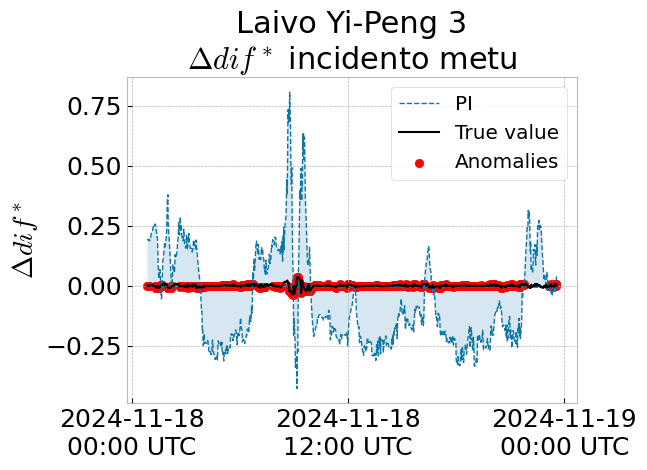

In [18]:
plot_pi(
    y_arr_smooth[:, 0, 0],
    y_low_dif[:, 1].reshape(-1),
    y_high_dif[:, 1].reshape(-1),
    r'$\Delta dif^*$',
    timestamps_smooth
)

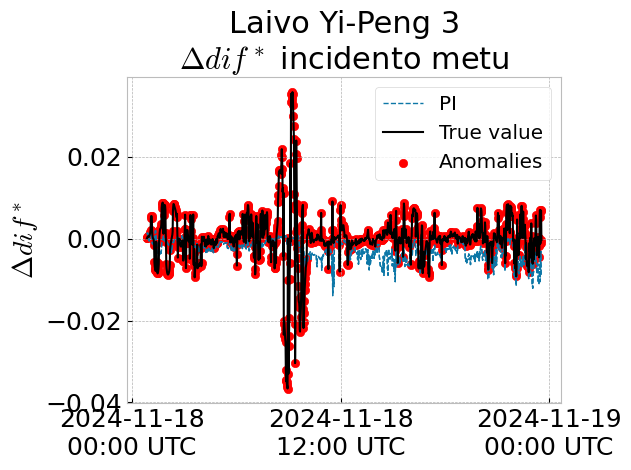

In [19]:
plot_pi(
    y_arr_smooth[:, 0, 0],
    y_low_dif[:, 1].reshape(-1),
    y_low_dif[:, 1].reshape(-1),
    r'$\Delta dif^*$',
    timestamps_smooth
)

In [20]:
plot_pi(
    y_arr_not_smooth[:, 0, 0],
    y_low_not_smooth[:, 0, 0],
    y_high_not_smooth[:, 0, 0],
    r'$\Delta dif^*$',
    timestamps_not_smooth
)

NameError: name 'y_low_not_smooth' is not defined

In [ ]:
np.mean( quantile_loss(0.025)( y_arr_smooth, y_low_smooth ) )

np.float64(0.029002030274781116)

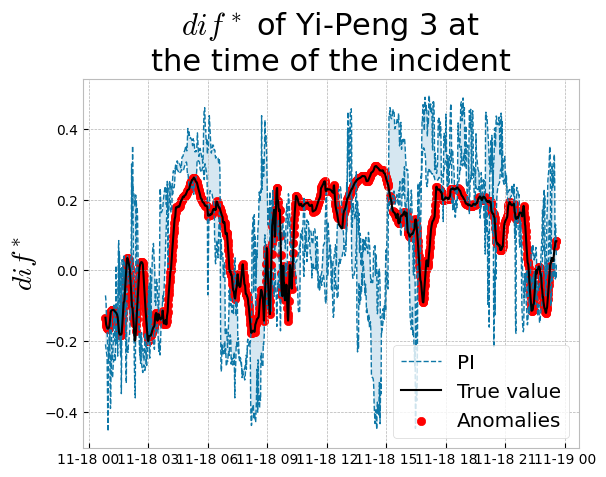

In [ ]:
plot_pi(
    y_arr_smooth[:, 24, 1],
    y_low_smooth[:, 24, 1],
    y_high_smooth[:, 24, 1],
    r'$dif^*$',
    timestamps_smooth
)

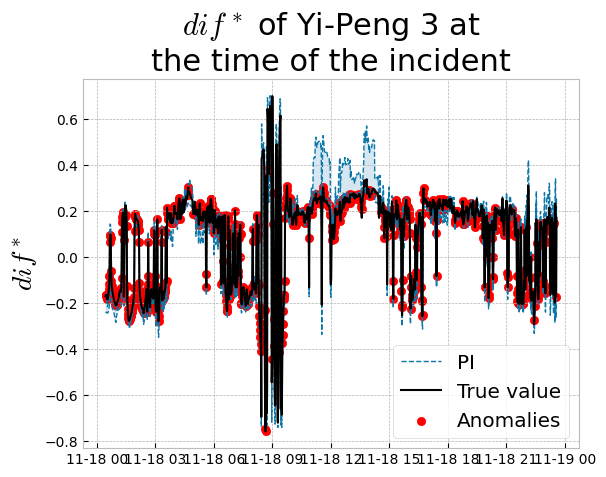

In [ ]:
plot_pi(
    y_arr_not_smooth[:, 0, 1],
    y_low_not_smooth[:, 0, 1],
    y_high_not_smooth[:, 0, 1],
    r'$dif^*$',
    timestamps_not_smooth
)

- Heading ir COG skiriasi matavimo tikslumas
- Pabandyti su moving average
- Pažiūrėti, kiek duomenų interpoliuota, koks pasiskirstymas


MMSI: 304473000 (HAV Dolphin), 311014800 (HAV Snapper)